# 1. Cellwise Euler vs. the implemented general Volterra scheme

This cell checks the **same approximative scheme** that is implemented by `volterra_vsig`, not the exact continuous Volterra equation.

For a coarse grid $0=t_0<\cdots<t_J=T$, the implemented general scheme computes

$$
\widehat V_j
=
\mathbf 1
+
\sum_{i=0}^{j}
\widehat V_{i-1}
\otimes
\mathcal E_{t_i,t_{i+1}}^{t_{j+1}}(\Delta Y_i),
\qquad
\widehat V_{-1}=\mathbf 1.
$$

The cellwise Euler reference uses the **same frozen left-point history** $\widehat V_{i-1}$, but approximates the local cell contribution

$$
\mathcal E_{t_i,t_{i+1}}^{t_{j+1}}(\Delta Y_i)
$$

by an Euler discretization on a dyadic partition of the single cell $[t_i,t_{i+1}]$. Thus, increasing `dyadic_order` should converge to `volterra_vsig` on the same coarse grid. This validates the local fractional coefficients and the indexing of the implemented approximative algorithm.


In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from tensordev.volterra.iteration import vsig_fft

jax.config.update("jax_enable_x64", True)

from tensordev.util.random_paths import random_trigonometric_polynomial_paths
from tensordev.volterra import VolterraKernel, vsig
from cell_euler import fractional_cell_euler_vsig


dtype = jnp.float64
key = jax.random.PRNGKey(0)

beta = 0.75
T = 1.0
steps = 8
batch = 4
dim = 2
trunc = 6
dt = T / steps

dyadic_orders = [0, 2, 4, 6, 8, 10]

X = random_trigonometric_polynomial_paths(
    key,
    batch=batch,
    steps=steps,
    dim=dim,
    n_modes=4,
    scale=0.35,
    decay=1.5,
    horizon=T,
).astype(dtype)

A = jnp.eye(dim, dtype=dtype)[None, :, :]

kernel = VolterraKernel.fractional(
    beta=jnp.array([beta], dtype=dtype),
    A=A,
)

target = vsig(
    X,
    kernel=kernel,
    dt=dt,
    trunc=trunc,
    axis=1,
)

rows = []

for dyadic_order in dyadic_orders:
    approx = fractional_cell_euler_vsig(
        X,
        beta=beta,
        A=A,
        dt=dt,
        trunc=trunc,
        axis=1,
        dyadic_order=dyadic_order,
    )

    for level, (a, b) in enumerate(zip(target, approx)):
        fscale = math.factorial(level)
        diff = (b.reshape((batch, -1)) - a.reshape((batch, -1))) * fscale

        rows.append(
            {
                "dyadic_order": dyadic_order,
                "level": level,
                "max_abs_entry": float(jnp.max(jnp.abs(diff))),
            }
        )

df_cell_euler = pd.DataFrame(rows)
compact_cell_euler = (
    df_cell_euler[df_cell_euler["level"] > 0]
    .groupby("dyadic_order", as_index=False)
    .agg(max_abs_entry=("max_abs_entry", "max"))
)

fig, ax = plt.subplots(figsize=(7, 4))
for level in sorted(df_cell_euler["level"].unique()):
    if level == 0:
        continue
    sub = df_cell_euler[df_cell_euler["level"] == level]
    ax.semilogy(sub["dyadic_order"], sub["max_abs_entry"], marker="o", label=f"level {level}")
ax.set_xlabel("dyadic order inside each coarse cell")
ax.set_ylabel("max abs entry  ($n!$-scaled)")
ax.set_title("Cellwise Euler convergence to volterra_vsig")
ax.grid(True, which="both")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(compact_cell_euler["dyadic_order"], compact_cell_euler["max_abs_entry"], marker="o", label="max abs entry")
ax.set_xlabel("dyadic order inside each coarse cell")
ax.set_ylabel("max abs entry  ($n!$-scaled levels)")
ax.set_title("Aggregate cellwise Euler error")


# 2. FSSK rough approximation vs. predictor-corrector reference

This cell compares a finite-state-space approximation of the fractional kernel to a direct predictor-corrector reference for the **true tensor-valued Volterra equation**.

The predictor-corrector target approximates

$$
V_t^{(0)}=1,
\qquad
V_t^{(n)}
=
\int_0^t
K_\beta(t-s)\,
V_s^{(n-1)}\otimes dY_s,
\qquad
K_\beta(u)=\frac{u^{\beta-1}}{\Gamma(\beta)}.
$$

The FSSK approximation replaces the fractional kernel by an exponential sum

$$
K_\beta(u)
\approx
\sum_{r=1}^R w_r e^{-\lambda_r u},
$$

and computes the corresponding finite-state-space signature. The error therefore measures the combined effect of the exponential-kernel approximation, the FSSK coefficient quadrature, and the finite predictor-corrector reference tolerance.


In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from tensordev.util.random_paths import random_trigonometric_polynomial_paths
from tensordev.sss import StateSpaceSignature
from tensordev.sss.rough_approx import fractional_fssk
from predictor_corrector import fractional_pc_vsig


# ---------------------------------------------------------------------
# Parameters
# ---------------------------------------------------------------------

dtype = jnp.float64
key = jax.random.PRNGKey(42)

beta = 0.75
T = 1.0

steps = 8
batch = 4
dim = 2
trunc = 6

dt = T / steps

# R = number of exponential factors / FSSK state dimension.
R_values = [2, 3, 4, 6, 8, 10]

# Predictor-corrector refinement inside the fractional reference solver.
pc_dyadic_order = 7

# FSSK coefficient contour quadrature order.
coef_quad_order = 64


# ---------------------------------------------------------------------
# Random paths
# ---------------------------------------------------------------------

X = random_trigonometric_polynomial_paths(
    key,
    batch=batch,
    steps=steps,
    dim=dim,
    n_modes=4,
    scale=0.35,
    decay=1.5,
    horizon=T,
).astype(dtype)

A = jnp.eye(dim, dtype=dtype)[None, :, :]  # q=1, m=d

print("X.shape:", X.shape)


# ---------------------------------------------------------------------
# Predictor-corrector target: true fractional tensor-valued Volterra equation
# ---------------------------------------------------------------------

pc_target = fractional_pc_vsig(
    X,
    beta=beta,
    A=A,
    dt=dt,
    trunc=trunc,
    axis=1,
    increment_input=False,
    dyadic_order=pc_dyadic_order,
    scheme="pc",
)

print("PC target level shapes:", [z.shape for z in pc_target])


# ---------------------------------------------------------------------
# Error helpers
# ---------------------------------------------------------------------

def _flatten_batch_level(z):
    z = jnp.asarray(z)
    return z.reshape((z.shape[0], -1))


def level_error_rows(ref, got, *, R):
    rows = []

    for level, (a, b) in enumerate(zip(ref, got)):
        fscale = math.factorial(level)
        diff = (_flatten_batch_level(b) - _flatten_batch_level(a)) * fscale

        rows.append(
            {
                "R": R,
                "level": level,
                "pc_shape": tuple(a.shape),
                "fssk_shape": tuple(b.shape),
                "max_abs_entry": float(jnp.max(jnp.abs(diff))),
            }
        )

    return rows


# ---------------------------------------------------------------------
# Compare FSSK rough approximations against PC target
# ---------------------------------------------------------------------

rows = []

for R in R_values:
    fssk_kernel = fractional_fssk(
        beta=beta,
        R=R,
        A=A,
        T=T,
        coef_quad_order=coef_quad_order,
        dtype=dtype,
    )

    fssk_sig = StateSpaceSignature(
        kernel=fssk_kernel,
        trunc=trunc,
    ).vsig(
        X,
        dt=dt,
        axis=1,
        increment_input=False,
    )

    rows.extend(level_error_rows(pc_target, fssk_sig, R=R))

df_fssk_pc = pd.DataFrame(rows)
compact_fssk_pc = (
    df_fssk_pc[df_fssk_pc["level"] > 0]
    .groupby("R", as_index=False)
    .agg(
        max_abs_entry=("max_abs_entry", "max"),
    )
)

fig, ax = plt.subplots(figsize=(7, 4))
for level in sorted(df_fssk_pc["level"].unique()):
    if level == 0:
        continue
    sub = df_fssk_pc[df_fssk_pc["level"] == level]
    ax.semilogy(sub["R"], sub["max_abs_entry"], marker="o", label=f"level {level}")
ax.set_xlabel("FSSK state dimension $R$")
ax.set_ylabel("max abs entry over batch  ($n!$-scaled)")
ax.set_title("FSSK rough approximation vs. PC reference")
ax.grid(True, which="both")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(compact_fssk_pc["R"], compact_fssk_pc["max_abs_entry"],    marker="o", label="max abs entry")
ax.set_xlabel("FSSK state dimension $R$")
ax.set_ylabel("max abs entry  ($n!$-scaled levels)")
ax.set_title("Aggregate FSSK-vs-PC error")
ax.grid(True, which="both")
ax.legend()
plt.show()


# 3. Semi-exact Volterra scheme (`vsig`) vs. predictor-corrector scheme as dyadic order increases

This cell compares how the **semi-exact scheme** (`vsig` with `VolterraKernel.fractional`) and the
**predictor-corrector scheme** (`fractional_pc_vsig`) each converge to a common reference as the
dyadic order grows. The reference is `fractional_pc_vsig` with `dyadic_order=8`.

The paths live on a fixed coarse grid of 16 steps. Both schemes receive the same paths; only
`dyadic_order` varies. For `vsig`, increasing `dyadic_order` refines every coarse increment into
`2**dyadic_order` equal sub-increments while keeping the exact fractional coefficients on each
sub-interval. For `fractional_pc_vsig`, it linearly refines the product-integration quadrature.


In [1]:
import math
import time
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from tensordev.util.random_paths import random_trigonometric_polynomial_paths, unit_speed_paths
from tensordev.volterra import VolterraKernel, vsig, vsig_fft
from predictor_corrector import fractional_pc_vsig

# ── Parameters ──────────────────────────────────────────────────────────────
dtype = jnp.float64
key = jax.random.PRNGKey(7)

beta = 0.8
T = 1.0
steps = 10
batch = 4
dim = 2
trunc = 6
dt = T / steps

ref_dyadic_order = 9
dyadic_orders = [0, 1, 2, 3, 4, 5]
n_timing_repeats = 3  # averaged over this many post-warmup runs
exclude_levels = {0, 1}  # set of levels to hide from per-level plots (e.g. {0} or {0, 1})

# ── Random paths ─────────────────────────────────────────────────────────────
# ── Unit-speed paths ─────────────────────────────────────────────────────────
# unit_speed_paths is defined on [0, 1], so this matches T = 1.0.
# dt_fine must divide dt; dt / 1024 is safe for dyadic-style grids.
X = jnp.asarray(
    unit_speed_paths(
        dt=dt,
        dt_fine=dt / 1024,
        n_paths=batch,
        dim=dim,
        seed=7,
        dtype=float,
    ),
    dtype=dtype,
)

A = jnp.eye(dim, dtype=dtype)[None, :, :]

print("X.shape:", X.shape)

# ── VolterraKernel for vsig ──────────────────────────────────────────────────
kernel = VolterraKernel.fractional(
    beta=jnp.array([beta], dtype=dtype),
    A=A,
)

# ── Reference: PC with high dyadic order ────────────────────────────────────
print(f"\nComputing reference (PC dyadic_order={ref_dyadic_order}) …", end=" ", flush=True)
t0 = time.perf_counter()
reference = fractional_pc_vsig(
    X,
    beta=beta,
    A=A,
    dt=dt,
    trunc=trunc,
    axis=1,
    increment_input=False,
    dyadic_order=ref_dyadic_order,
    scheme="pc",
)
jax.block_until_ready(reference)
print(f"done in {time.perf_counter() - t0:.2f}s")
print("Reference level shapes:", [z.shape for z in reference])

# ── Timing helper ─────────────────────────────────────────────────────────────
def _timed(fn, n_repeats):
    """Run fn() once for JIT warmup, then average over n_repeats calls."""
    result = fn()
    jax.block_until_ready(result)          # warmup / compile
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        result = fn()
        jax.block_until_ready(result)
    return result, (time.perf_counter() - t0) / n_repeats

# ── Error helper ─────────────────────────────────────────────────────────────
def _level_errors(ref, got):
    rows = []
    for level, (a, b) in enumerate(zip(ref, got)):
        fscale = math.factorial(level)
        diff = (jnp.asarray(b).reshape((batch, -1)) - jnp.asarray(a).reshape((batch, -1))) * fscale
        rows.append(dict(
            level=level,
            max_abs_entry=float(jnp.max(jnp.abs(diff))),
        ))
    return rows

# ── Sweep over dyadic orders ─────────────────────────────────────────────────
rows_vsig = []
rows_pc   = []
timing_vsig = {}
timing_pc   = {}

total = len(dyadic_orders)
print(f"\nSweeping {total} dyadic orders …\n{'─'*52}")

for idx, d in enumerate(dyadic_orders, 1):
    print(f"[{idx:{len(str(total))}d}/{total}] dyadic_order={d}")

    # ── vsig ──
    print(f"          vsig  … ", end="", flush=True)
    out_vsig, t_vsig = _timed(
        lambda d=d: vsig_fft(X, kernel=kernel, dt=dt, trunc=trunc, axis=1, dyadic_order=d),
        n_timing_repeats,
    )
    timing_vsig[d] = t_vsig
    for row in _level_errors(reference, out_vsig):
        row["dyadic_order"] = d
        rows_vsig.append(row)
    print(f"{t_vsig*1e3:8.1f} ms")

    # ── PC ──
    print(f"          PC    … ", end="", flush=True)
    out_pc, t_pc = _timed(
        lambda d=d: fractional_pc_vsig(
            X, beta=beta, A=A, dt=dt, trunc=trunc,
            axis=1, increment_input=False, dyadic_order=d, scheme="pc",
        ),
        n_timing_repeats,
    )
    timing_pc[d] = t_pc
    for row in _level_errors(reference, out_pc):
        row["dyadic_order"] = d
        rows_pc.append(row)
    print(f"{t_pc*1e3:8.1f} ms")

print(f"{'─'*52}\nDone.")

df_vsig = pd.DataFrame(rows_vsig)
df_pc   = pd.DataFrame(rows_pc)

timing_df = pd.DataFrame({
    "dyadic_order": dyadic_orders,
    "vsig_ms":      [timing_vsig[d] * 1e3 for d in dyadic_orders],
    "pc_ms":        [timing_pc[d]   * 1e3 for d in dyadic_orders],
})
print("\nTiming summary (ms, averaged over", n_timing_repeats, "runs):")
print(timing_df.to_string(index=False, float_format="{:.2f}".format))

def _compact(df):
    return (
        df[df["level"] > 0]
        .groupby("dyadic_order", as_index=False)
        .agg(
            max_abs_entry=("max_abs_entry", "max"),
        )
    )

compact_vsig = _compact(df_vsig)
compact_pc   = _compact(df_pc)



X.shape: (4, 11, 2)

Computing reference (PC dyadic_order=9) … done in 5.53s
Reference level shapes: [(4, 1), (4, 2), (4, 4), (4, 8), (4, 16), (4, 32), (4, 64)]

Sweeping 6 dyadic orders …
────────────────────────────────────────────────────
[1/6] dyadic_order=0
          vsig  …      6.5 ms
          PC    …      0.1 ms
[2/6] dyadic_order=1
          vsig  …      6.6 ms
          PC    …      0.2 ms
[3/6] dyadic_order=2
          vsig  …      6.7 ms
          PC    …      0.6 ms
[4/6] dyadic_order=3
          vsig  …      7.2 ms
          PC    …      2.2 ms
[5/6] dyadic_order=4
          vsig  …      9.3 ms
          PC    …      7.1 ms
[6/6] dyadic_order=5
          vsig  …     15.0 ms
          PC    …     26.0 ms
────────────────────────────────────────────────────
Done.

Timing summary (ms, averaged over 3 runs):
 dyadic_order  vsig_ms  pc_ms
            0     6.52   0.12
            1     6.62   0.24
            2     6.68   0.64
            3     7.18   2.16
            4     9

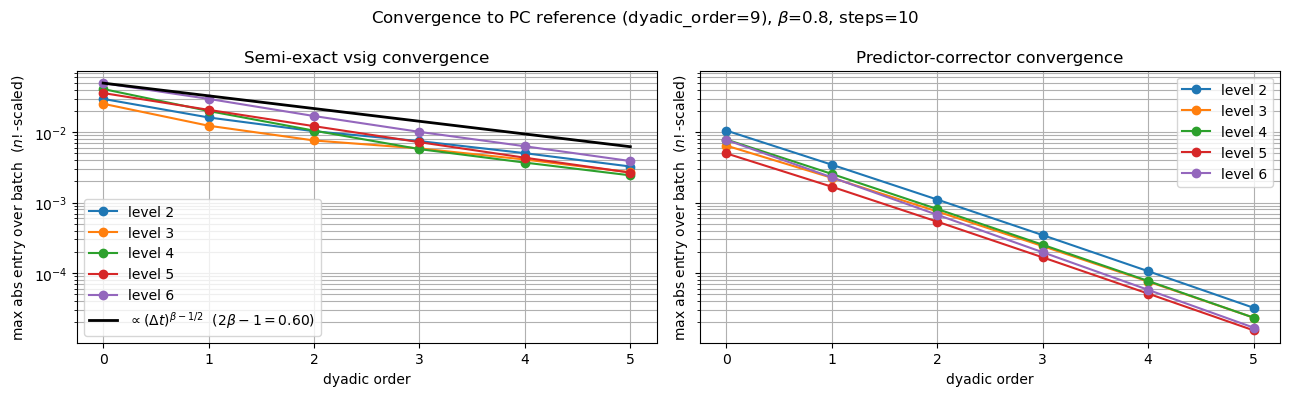

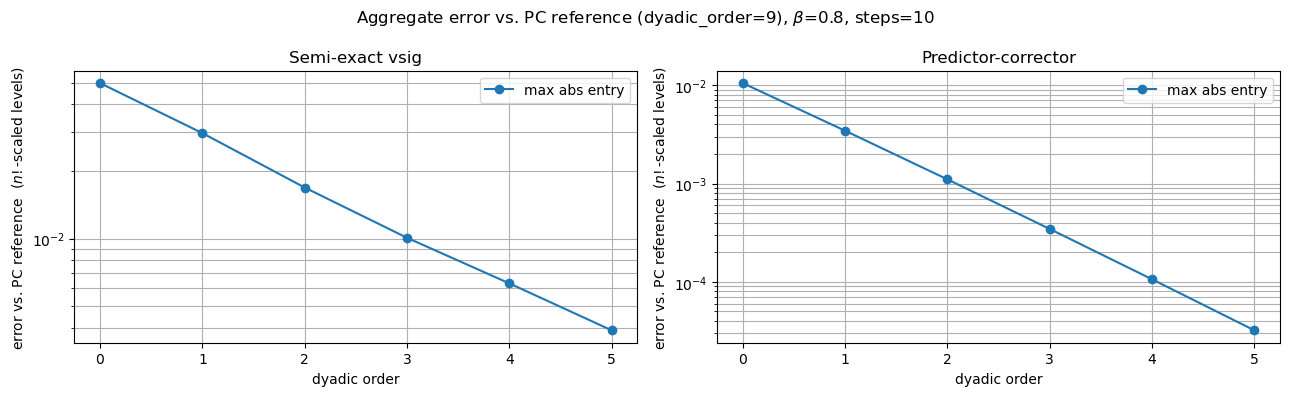

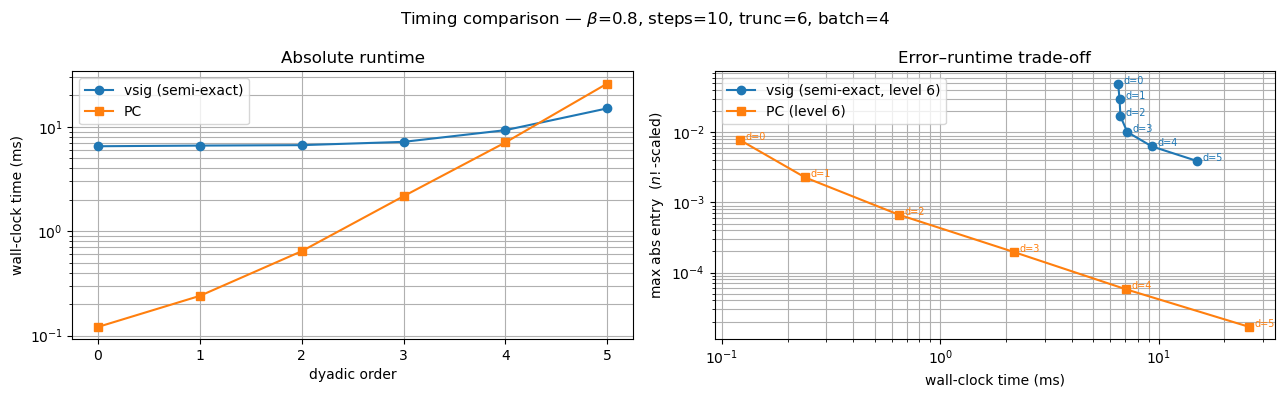

In [2]:
# ── Per-level convergence ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

plotted_levels_vsig = [lv for lv in sorted(df_vsig["level"].unique()) if lv not in exclude_levels]
for level in plotted_levels_vsig:
    sub = df_vsig[df_vsig["level"] == level]
    axes[0].semilogy(sub["dyadic_order"], sub["max_abs_entry"], marker="o", label=f"level {level}")

# Reference line  C · (dt / 2^d)^(β − ½),  anchored to the highest plotted level at d=0
if plotted_levels_vsig:
    ref_level = plotted_levels_vsig[-1]
    sub_ref = df_vsig[df_vsig["level"] == ref_level].set_index("dyadic_order")
    ref_vals = [(dt / 2**d) ** (2*(beta - 0.5)) for d in dyadic_orders]
    anchor   = float(sub_ref.loc[dyadic_orders[0], "max_abs_entry"])
    scale    = anchor / ref_vals[0]
    axes[0].semilogy(
        dyadic_orders, [scale * v for v in ref_vals],
        linestyle="-", color="black", linewidth=2,
        label=f"$\\propto (\\Delta t)^{{\\beta-1/2}}$  ($2\\beta-1={2*beta - 1:.2f}$)",
    )

axes[0].set_xlabel("dyadic order")
axes[0].set_ylabel("max abs entry over batch  ($n!$-scaled)")
axes[0].set_title("Semi-exact vsig convergence")
axes[0].grid(True, which="both")
axes[0].legend()

for level in sorted(df_pc["level"].unique()):
    if level in exclude_levels:
        continue
    sub = df_pc[df_pc["level"] == level]
    axes[1].semilogy(sub["dyadic_order"], sub["max_abs_entry"], marker="o", label=f"level {level}")
axes[1].set_xlabel("dyadic order")
axes[1].set_title("Predictor-corrector convergence")
axes[1].set_ylabel("max abs entry over batch  ($n!$-scaled)")
axes[1].grid(True, which="both")
axes[1].legend()

plt.suptitle(
    f"Convergence to PC reference (dyadic_order={ref_dyadic_order}), "
    f"$\\beta$={beta}, steps={steps}"
)
plt.tight_layout()
plt.show()

# ── Aggregate comparison ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, compact, title in [
    (axes[0], compact_vsig, "Semi-exact vsig"),
    (axes[1], compact_pc,   "Predictor-corrector"),
]:
    ax.semilogy(compact["dyadic_order"], compact["max_abs_entry"],    marker="o", label="max abs entry")
    ax.set_xlabel("dyadic order")
    ax.set_ylabel("error vs. PC reference  ($n!$-scaled levels)")
    ax.set_title(title)
    ax.grid(True, which="both")
    ax.legend()

plt.suptitle(
    f"Aggregate error vs. PC reference (dyadic_order={ref_dyadic_order}), "
    f"$\\beta$={beta}, steps={steps}"
)
plt.tight_layout()
plt.show()

# ── Timing comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Absolute wall-clock time
axes[0].semilogy(timing_df["dyadic_order"], timing_df["vsig_ms"], marker="o", label="vsig (semi-exact)")
axes[0].semilogy(timing_df["dyadic_order"], timing_df["pc_ms"],   marker="s", label="PC")
axes[0].set_xlabel("dyadic order")
axes[0].set_ylabel("wall-clock time (ms)")
axes[0].set_title("Absolute runtime")
axes[0].grid(True, which="both")
axes[0].legend()

# Error vs. time trade-off (max rel L2 of highest non-zero level)
max_level = df_vsig["level"].max()
sub_vsig = df_vsig[df_vsig["level"] == max_level].set_index("dyadic_order")
sub_pc   = df_pc[df_pc["level"] == max_level].set_index("dyadic_order")

for d in dyadic_orders:
    axes[1].annotate(
        f"d={d}",
        xy=(timing_vsig[d] * 1e3, float(sub_vsig.loc[d, "max_abs_entry"])),
        fontsize=7, color="tab:blue", xytext=(4, 0), textcoords="offset points",
    )
    axes[1].annotate(
        f"d={d}",
        xy=(timing_pc[d] * 1e3, float(sub_pc.loc[d, "max_abs_entry"])),
        fontsize=7, color="tab:orange", xytext=(4, 0), textcoords="offset points",
    )

axes[1].loglog(
    [timing_vsig[d] * 1e3 for d in dyadic_orders],
    [float(sub_vsig.loc[d, "max_abs_entry"]) for d in dyadic_orders],
    marker="o", label=f"vsig (semi-exact, level {max_level})",
)
axes[1].loglog(
    [timing_pc[d] * 1e3 for d in dyadic_orders],
    [float(sub_pc.loc[d, "max_abs_entry"]) for d in dyadic_orders],
    marker="s", label=f"PC (level {max_level})",
)
axes[1].set_xlabel("wall-clock time (ms)")
axes[1].set_ylabel("max abs entry  ($n!$-scaled)")
axes[1].set_title("Error–runtime trade-off")
axes[1].grid(True, which="both")
axes[1].legend()

plt.suptitle(
    f"Timing comparison — $\\beta$={beta}, steps={steps}, "
    f"trunc={trunc}, batch={batch}"
)
plt.tight_layout()
plt.show()
